# Is the Golden Leaf Still Profitable: Analyzing the Impact of Weather and Inflation on Zimbabwe’s Tobacco Market (2022–2025)

**Author:** Priscillah C & Philipa M 
**Date:** July 2025

## Project Goals
- Analyze how rainfall and inflation affect tobacco sales and prices in Zimbabwe.
- Quantify their impacts and build time series/regression models for insight and forecasting.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional for time series/regression:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.linear_model import LinearRegression
import plotly.express as px

# For date handling:
from datetime import datetime


In [7]:
# loading our datasets
sales_df = pd.read_csv("tobacco_sales_data.csv", delimiter =';')
rainfall_df = pd.read_csv("rainfall_zimbabwe_annual.csv")
inflation_df = pd.read_excel("inflation.xlsx")

# Quick previews
print(sales_df.head())
print(rainfall_df.head())
print(inflation_df.head())


         date  year  day_number  auction_weight_kg  auction_price_usd  \
0  2025/07/22  2025          96           19507119               3.57   
1  2025/07/21  2025          95           19467767               3.57   
2  2025/07/18  2025          94           19427361               3.57   
3  2025/07/17  2025          93           19397720               3.58   
4  2025/07/16  2025          92           19328162               3.58   

   contract_weight_kg  contract_price_usd  combined_weight_kg  \
0         328566854.0                3.31         348073973.0   
1         328263865.0                3.31         347731632.0   
2         327847311.0                3.32         347274672.0   
3         326699086.0                3.32         346096806.0   
4         325608711.0                3.32         344936873.0   

   combined_price_usd  rejection_rate_auction  rejection_rate_contract  month  \
0                3.33                   15.77                     2.14      7   
1       

In [8]:
import pandas as pd

# Load datasets
sales_df = pd.read_csv("tobacco_sales_data.csv", delimiter=';')
rainfall_df = pd.read_csv("rainfall_zimbabwe_annual.csv")
inflation_df = pd.read_excel("inflation.xlsx")

# --- Clean sales_df ---
# Convert date to datetime
sales_df["date"] = pd.to_datetime(sales_df["date"], errors="coerce")

# Extract year (to merge later)
sales_df["year"] = sales_df["date"].dt.year

# --- Clean rainfall_df ---
rainfall_df = rainfall_df.rename(columns={"season_year": "year"})  # rename to match
rainfall_df["year"] = rainfall_df["year"].astype(int)

# --- Clean inflation_df ---
inflation_df["year"] = inflation_df["year"].astype(int)

# --- Merge everything ---
merged_df = (
    sales_df
    .merge(rainfall_df, on="year", how="left")
    .merge(inflation_df, on="year", how="left")
)

# Preview merged dataset
print(merged_df.head(10))


        date  year  day_number  auction_weight_kg  auction_price_usd  \
0 2025-07-22  2025          96           19507119               3.57   
1 2025-07-21  2025          95           19467767               3.57   
2 2025-07-18  2025          94           19427361               3.57   
3 2025-07-17  2025          93           19397720               3.58   
4 2025-07-16  2025          92           19328162               3.58   
5 2025-07-15  2025          91           19238128               3.59   
6 2025-07-14  2025          90           19136319               3.61   
7 2025-07-11  2025          89           19041953               3.60   
8 2025-07-10  2025          88           18957334               3.60   
9 2025-07-09  2025          87           18825426               3.61   

   contract_weight_kg  contract_price_usd  combined_weight_kg  \
0         328566854.0                3.31         348073973.0   
1         328263865.0                3.31         347731632.0   
2         32

In [9]:
print(merged_df.tail(10))


          date  year  day_number  auction_weight_kg  auction_price_usd  \
365 2022-05-20  2022          35            6873274               3.13   
366 2022-05-19  2022          34            6752185               3.12   
367 2022-05-17  2022          32            6278500               3.11   
368 2022-05-16  2022          31            6012416               3.10   
369 2022-05-13  2022          30            5837475               3.15   
370 2022-05-12  2022          29            5753382               3.15   
371 2022-05-11  2022          28            5546180               3.15   
372 2022-05-10  2022          27            5272017               3.15   
373 2022-05-09  2022          26            5007237               3.15   
374 2022-05-06  2022          25            4742300               3.15   

     contract_weight_kg  contract_price_usd  combined_weight_kg  \
365          92494231.0                2.97          99367505.0   
366          89894625.0                2.97        

In [10]:
# --- Step 1: Dataset Information & Missing Values ---

print("=== Sales Data ===")
print(sales_df.info())   # column types + non-null counts
print(sales_df.describe(include="all"))  # summary stats
print("\nMissing values per column in sales data:\n", sales_df.isnull().sum())

print("\n=== Rainfall Data ===")
print(rainfall_df.info())
print(rainfall_df.describe(include="all"))
print("\nMissing values per column in rainfall data:\n", rainfall_df.isnull().sum())

print("\n=== Inflation Data ===")
print(inflation_df.info())
print(inflation_df.describe(include="all"))
print("\nMissing values per column in inflation data:\n", inflation_df.isnull().sum())


=== Sales Data ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date                      375 non-null    datetime64[ns]
 1   year                      375 non-null    int32         
 2   day_number                375 non-null    int64         
 3   auction_weight_kg         375 non-null    int64         
 4   auction_price_usd         375 non-null    float64       
 5   contract_weight_kg        375 non-null    float64       
 6   contract_price_usd        375 non-null    float64       
 7   combined_weight_kg        375 non-null    float64       
 8   combined_price_usd        375 non-null    float64       
 9   rejection_rate_auction    375 non-null    float64       
 10  rejection_rate_contract   375 non-null    float64       
 11  month                     375 non-null    int64         
 12  wee

# Exploratory Data Analysis

**EXPLORATORY DATA ANALYSIS**

*Sales and Price Dynamics*

Tobacco is Zimbabwe’s most valuable agricultural export, and understanding its sales volumes and price dynamics is crucial for evaluating profitability. In this step, we will:

**Examine annual trends in sales volumes**

- How much tobacco is being sold each year (auction vs. contract).

- Detect whether production is increasing, stable, or declining.

**Analyze tobacco price movements**

- Track average auction and contract prices per kg over time.

- Identify whether prices are volatile or follow a steady trend.

**Compare sales vs. price interactions**

- Do higher sales volumes lead to lower prices (oversupply effect)?

- Are prices resilient during years of low production?

**Visualize sales and price trends**

- Use line and bar charts to highlight dynamics between 2015–2025.

- Show both annual sales weight (kg) and average prices (USD/kg).

This step establishes the core market trends for Zimbabwe’s tobacco sector before we layer in the impact of climate (rainfall) and economic conditions (inflation).

Sales columns: ['date', 'year', 'day_number', 'auction_weight_kg', 'auction_price_usd', 'contract_weight_kg', 'contract_price_usd', 'combined_weight_kg', 'combined_price_usd', 'rejection_rate_auction', 'rejection_rate_contract', 'month', 'week', 'quarter', 'price_gap_ac', 'weight_gap_ac', 'total_rejection_pressure', 'rolling_avg_price', 'rolling_rejection_rate']
Final Merged Data ===
   year  total_volume_kg  avg_price_usd   revenue_usd  rainfall_mm  \
0  2022      208279247.0       3.024684  6.299789e+08   628.177053   
1  2023      295660862.0       2.998054  8.864074e+08   407.517718   
2  2024      231678225.0       3.462527  8.021922e+08   424.287110   
3  2025      348073973.0       3.397218  1.182483e+09   508.818652   

   inflation_rate_pct  
0              193.00  
1              667.36  
2              736.11  
3               92.17  


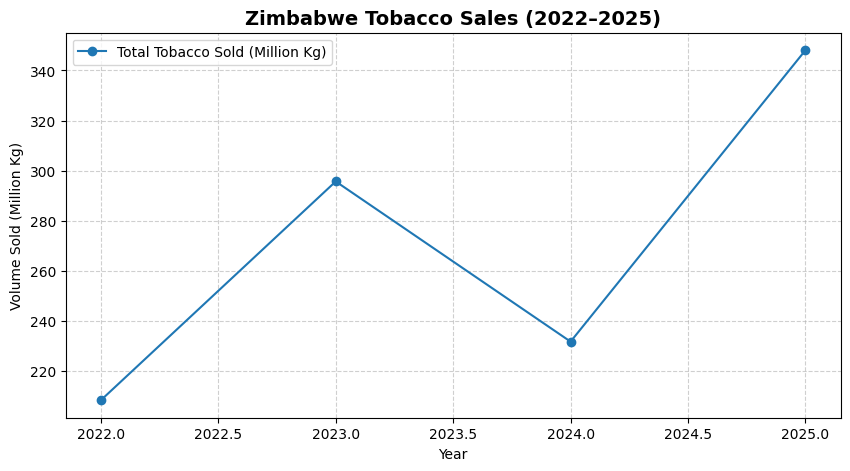

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Load your data ---
sales_df = pd.read_csv("tobacco_sales_data.csv ", delimiter =';')
rainfall_df = pd.read_csv("rainfall_zimbabwe_annual.csv")
inflation_df = pd.read_excel("inflation.xlsx")

# --- Clean column names (strip spaces, lowercase) ---
sales_df.columns = sales_df.columns.str.strip().str.lower()
rainfall_df.columns = rainfall_df.columns.str.strip().str.lower()
inflation_df.columns = inflation_df.columns.str.strip().str.lower()

# --- Rename for consistency ---
rainfall_df = rainfall_df.rename(columns={"season_year": "year"})
inflation_df = inflation_df.rename(columns={"inflation rate (%)": "inflation_rate_pct"})

# --- Debug check ---
print("Sales columns:", sales_df.columns.tolist())

# --- Aggregate yearly totals ---
yearly_sales = (
    sales_df.groupby("year").agg(
        total_volume_kg=("combined_weight_kg", "max"),   # cumulative max value per year
        avg_price_usd=("combined_price_usd", "mean")     # yearly avg price
    )
    .reset_index()
)

# --- Compute yearly revenue ---
yearly_sales["revenue_usd"] = yearly_sales["total_volume_kg"] * yearly_sales["avg_price_usd"]

# --- Merge with rainfall & inflation ---
merged_df = (
    yearly_sales
    .merge(rainfall_df, on="year", how="left")
    .merge(inflation_df, on="year", how="left")
)

print("Final Merged Data ===")
print(merged_df)

# --- Plot total volume ---
plt.figure(figsize=(10,5))
plt.plot(merged_df["year"], merged_df["total_volume_kg"]/1e6, marker="o", label="Total Tobacco Sold (Million Kg)")
plt.title("Zimbabwe Tobacco Sales (2022–2025)", fontsize=14, weight="bold")
plt.xlabel("Year")
plt.ylabel("Volume Sold (Million Kg)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()


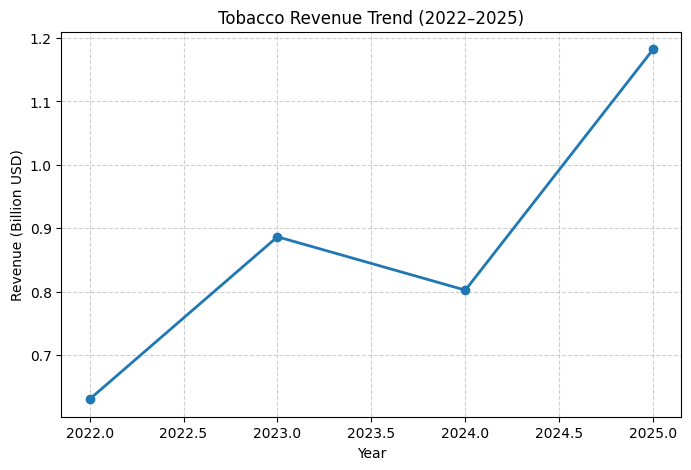

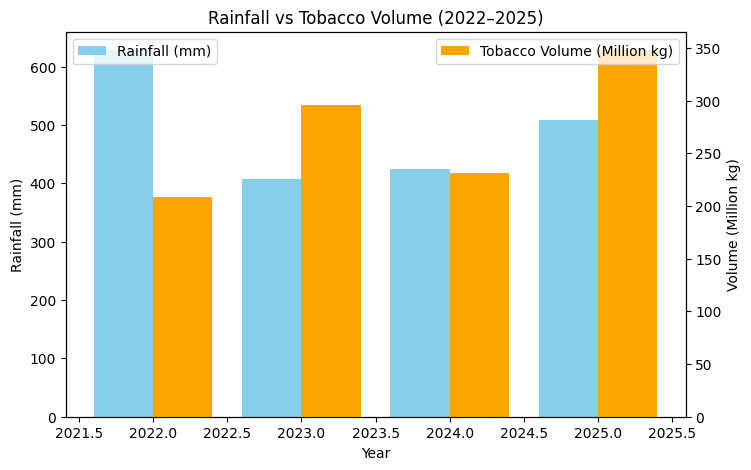

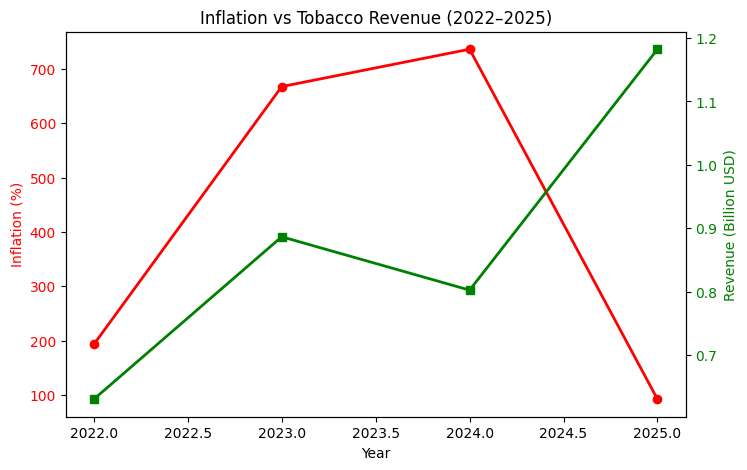

In [15]:
import matplotlib.pyplot as plt

# --- Revenue Trend ---
plt.figure(figsize=(8,5))
plt.plot(merged_df["year"], merged_df["revenue_usd"]/1e9, marker="o", linewidth=2)
plt.title("Tobacco Revenue Trend (2022–2025)")
plt.xlabel("Year")
plt.ylabel("Revenue (Billion USD)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# --- Rainfall vs Volume ---
fig, ax1 = plt.subplots(figsize=(8,5))

ax1.bar(merged_df["year"]-0.2, merged_df["rainfall_mm"], width=0.4, label="Rainfall (mm)", color="skyblue")
ax2 = ax1.twinx()
ax2.bar(merged_df["year"]+0.2, merged_df["total_volume_kg"]/1e6, width=0.4, label="Tobacco Volume (Million kg)", color="orange")

ax1.set_xlabel("Year")
ax1.set_ylabel("Rainfall (mm)")
ax2.set_ylabel("Volume (Million kg)")
plt.title("Rainfall vs Tobacco Volume (2022–2025)")

# Add legends
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.show()

# --- Inflation vs Revenue ---
fig, ax1 = plt.subplots(figsize=(8,5))

ax1.plot(merged_df["year"], merged_df["inflation_rate_pct"], color="red", marker="o", linewidth=2, label="Inflation (%)")
ax1.set_xlabel("Year")
ax1.set_ylabel("Inflation (%)", color="red")
ax1.tick_params(axis="y", labelcolor="red")

ax2 = ax1.twinx()
ax2.plot(merged_df["year"], merged_df["revenue_usd"]/1e9, color="green", marker="s", linewidth=2, label="Revenue (Billion USD)")
ax2.set_ylabel("Revenue (Billion USD)", color="green")
ax2.tick_params(axis="y", labelcolor="green")

plt.title("Inflation vs Tobacco Revenue (2022–2025)")
plt.show()


# Correlation Analysis

Correlation Matrix:
                     total_volume_kg  avg_price_usd  revenue_usd  rainfall_mm  \
total_volume_kg            1.000000       0.235796     0.962151    -0.347721   
avg_price_usd              0.235796       1.000000     0.487317    -0.289001   
revenue_usd                0.962151       0.487317     1.000000    -0.346540   
rainfall_mm               -0.347721      -0.289001    -0.346540     1.000000   
inflation_rate_pct        -0.279751       0.033545    -0.288880    -0.796159   

                    inflation_rate_pct  
total_volume_kg              -0.279751  
avg_price_usd                 0.033545  
revenue_usd                  -0.288880  
rainfall_mm                  -0.796159  
inflation_rate_pct            1.000000  


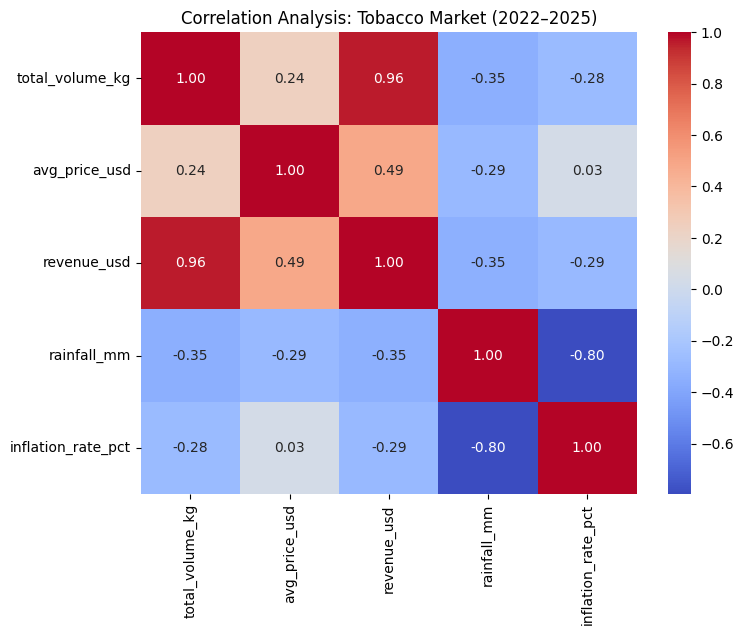

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Select relevant variables ---
corr_data = merged_df[["total_volume_kg", "avg_price_usd", "revenue_usd", "rainfall_mm", "inflation_rate_pct"]]

# --- Compute correlation matrix ---
corr_matrix = corr_data.corr()

print("Correlation Matrix:\n", corr_matrix)

# --- Plot heatmap ---
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", cbar=True)
plt.title("Correlation Analysis: Tobacco Market (2022–2025)")
plt.show()


# Trend Analysis


📊 Trend Analysis (Nominal vs Real Revenue, YoY % Changes):

   year  total_volume_kg  avg_price_usd   revenue_usd  real_revenue_usd  \
0  2022        208279247           3.02  6.300000e+08      6.300000e+08   
1  2023        295660862           3.00  8.860000e+08      1.154608e+08   
2  2024        231678225           3.46  8.020000e+08      1.250005e+07   
3  2025        348073973           3.40  1.180000e+09      9.570483e+06   

   volume_yoy_pct  price_yoy_pct  nominal_rev_yoy_pct  real_rev_yoy_pct  
0             NaN            NaN                  NaN               NaN  
1       41.954067      -0.662252            40.634921        -81.672889  
2      -21.640550      15.333333            -9.480813        -89.173771  
3       50.240262      -1.734104            47.132170        -23.436452  


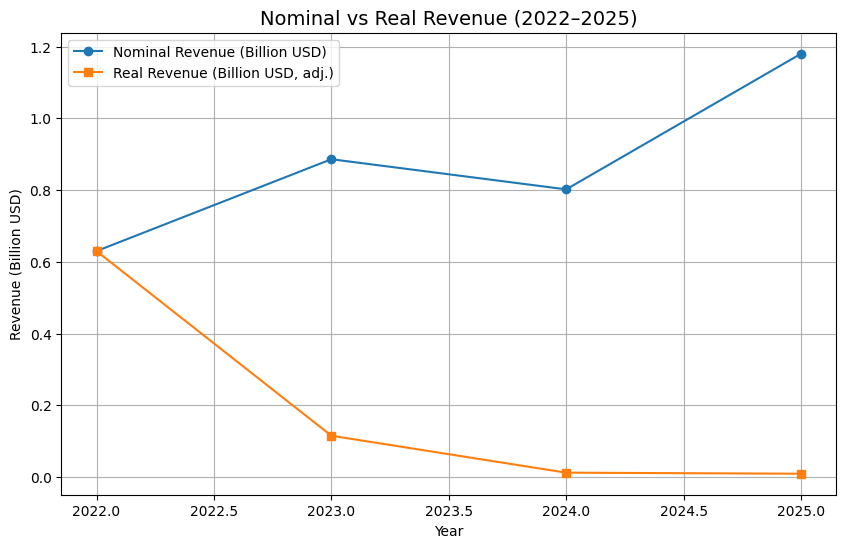

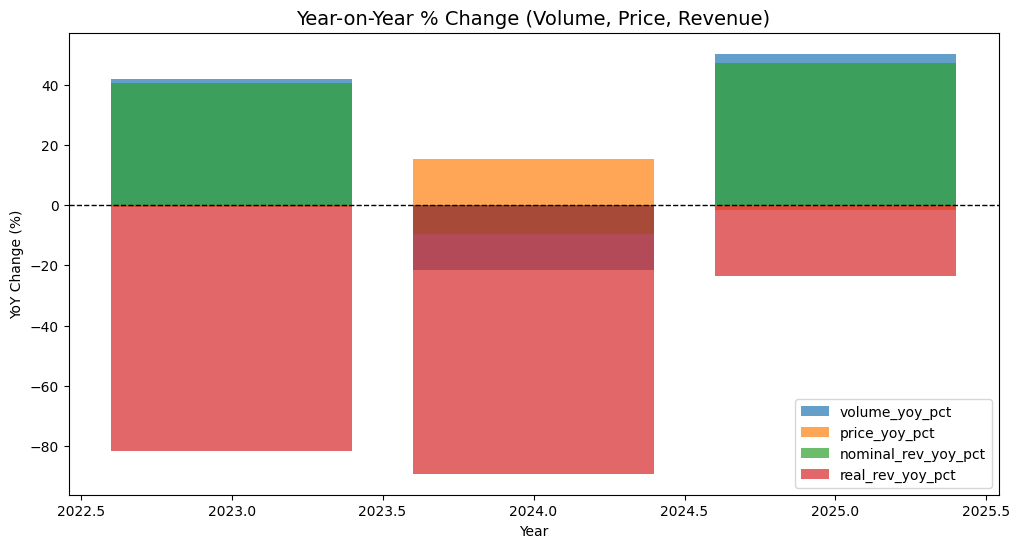

In [17]:
import pandas as pd
import matplotlib.pyplot as plt


data = {
    "year": [2022, 2023, 2024, 2025],
    "total_volume_kg": [208279247, 295660862, 231678225, 348073973],
    "avg_price_usd": [3.02, 3.00, 3.46, 3.40],
    "revenue_usd": [6.30e8, 8.86e8, 8.02e8, 1.18e9],
    "inflation_rate_pct": [193.0, 667.36, 736.11, 92.17],
}
df = pd.DataFrame(data)

# === Step 1: Build Inflation Index (Base year = 2022 = 100) ===
df["inflation_index"] = (1 + df["inflation_rate_pct"]/100).cumprod()
df["inflation_index"] = df["inflation_index"] / df["inflation_index"].iloc[0] * 100

# === Step 2: Adjust Revenue to Real Terms ===
df["real_revenue_usd"] = df["revenue_usd"] / (df["inflation_index"] / 100)

# === Step 3: Calculate Year-on-Year % Changes ===
df["volume_yoy_pct"] = df["total_volume_kg"].pct_change() * 100
df["price_yoy_pct"] = df["avg_price_usd"].pct_change() * 100
df["nominal_rev_yoy_pct"] = df["revenue_usd"].pct_change() * 100
df["real_rev_yoy_pct"] = df["real_revenue_usd"].pct_change() * 100

# === Display summary ===
print("\n📊 Trend Analysis (Nominal vs Real Revenue, YoY % Changes):\n")
print(df[["year", "total_volume_kg", "avg_price_usd", "revenue_usd", 
          "real_revenue_usd", "volume_yoy_pct", "price_yoy_pct", 
          "nominal_rev_yoy_pct", "real_rev_yoy_pct"]])

# === Step 4: Plot Revenue Trends ===
plt.figure(figsize=(10,6))
plt.plot(df["year"], df["revenue_usd"]/1e9, marker="o", label="Nominal Revenue (Billion USD)")
plt.plot(df["year"], df["real_revenue_usd"]/1e9, marker="s", label="Real Revenue (Billion USD, adj.)")
plt.title("Nominal vs Real Revenue (2022–2025)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Revenue (Billion USD)")
plt.legend()
plt.grid(True)
plt.show()

# === Step 5: Plot YoY Growth ===
df_plot = df.melt(id_vars="year", 
                  value_vars=["volume_yoy_pct","price_yoy_pct","nominal_rev_yoy_pct","real_rev_yoy_pct"],
                  var_name="Metric", value_name="YoY Change (%)")

plt.figure(figsize=(12,6))
for metric in df_plot["Metric"].unique():
    subset = df_plot[df_plot["Metric"]==metric]
    plt.bar(subset["year"], subset["YoY Change (%)"], alpha=0.7, label=metric)

plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Year-on-Year % Change (Volume, Price, Revenue)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("YoY Change (%)")
plt.legend()
plt.show()


# Rainfall Impact

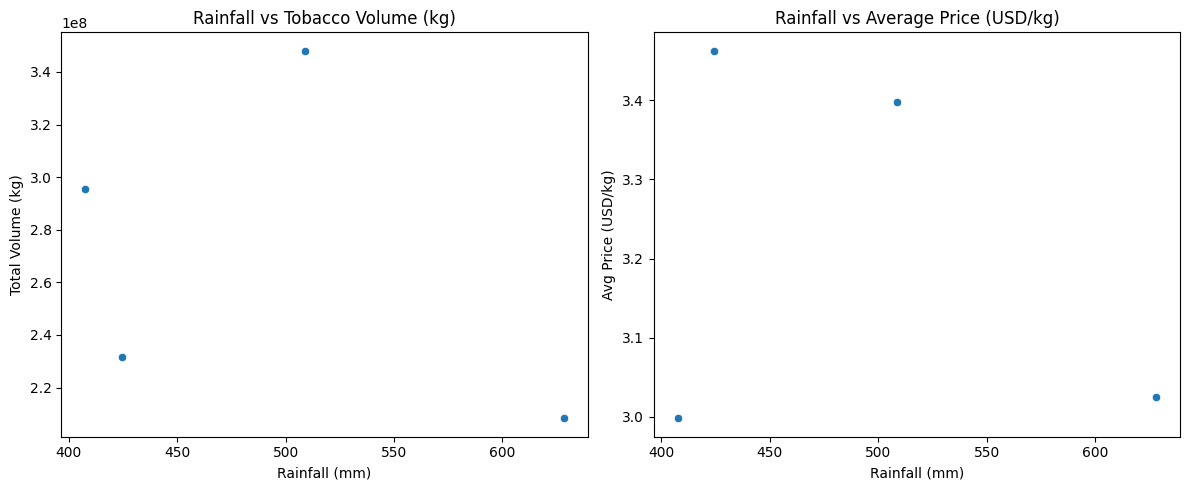

Simple Regression: Volume ~ Rainfall
                            OLS Regression Results                            
Dep. Variable:        total_volume_kg   R-squared:                       0.121
Model:                            OLS   Adj. R-squared:                 -0.319
Method:                 Least Squares   F-statistic:                    0.2751
Date:                Thu, 11 Sep 2025   Prob (F-statistic):              0.652
Time:                        19:35:01   Log-Likelihood:                -76.698
No. Observations:                   4   AIC:                             157.4
Df Residuals:                       2   BIC:                             156.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        

C:\Users\Surface Laptop Go\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 4 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
C:\Users\Surface Laptop Go\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 4 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
C:\Users\Surface Laptop Go\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 4 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
C:\Users\Surface Laptop Go\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normte

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# --- Assume merged_df is already created ---
# Columns: year, total_volume_kg, avg_price_usd, revenue_usd, rainfall_mm, inflation_rate_pct

# =====================================================
# 1. Scatterplots
# =====================================================
plt.figure(figsize=(12, 5))

# Rainfall vs Volume
plt.subplot(1, 2, 1)
sns.scatterplot(data=merged_df, x="rainfall_mm", y="total_volume_kg")
plt.title("Rainfall vs Tobacco Volume (kg)")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Total Volume (kg)")

# Rainfall vs Price
plt.subplot(1, 2, 2)
sns.scatterplot(data=merged_df, x="rainfall_mm", y="avg_price_usd")
plt.title("Rainfall vs Average Price (USD/kg)")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Avg Price (USD/kg)")

plt.tight_layout()
plt.show()

# =====================================================
# 2. Simple Regression (Rainfall → Volume, Price)
# =====================================================
X = sm.add_constant(merged_df["rainfall_mm"])

# Volume model
y_volume = merged_df["total_volume_kg"]
model_volume = sm.OLS(y_volume, X).fit()

# Price model
y_price = merged_df["avg_price_usd"]
model_price = sm.OLS(y_price, X).fit()

print("Simple Regression: Volume ~ Rainfall")
print(model_volume.summary())
print("\nSimple Regression: Price ~ Rainfall")
print(model_price.summary())

# =====================================================
# 3. Multiple Regression (Rainfall + Inflation → Volume)
# =====================================================
X_multi = merged_df[["rainfall_mm", "inflation_rate_pct"]]
X_multi = sm.add_constant(X_multi)
y_multi = merged_df["total_volume_kg"]

model_multi = sm.OLS(y_multi, X_multi).fit()
print("\nMultiple Regression: Volume ~ Rainfall + Inflation")
print(model_multi.summary())

# =====================================================
# 4. Lag Analysis (Rainfall_{t-1} → Volume_t, Price_t)
# =====================================================
merged_df["rainfall_lag1"] = merged_df["rainfall_mm"].shift(1)

# Regression with lag for volume
X_lag_vol = sm.add_constant(merged_df["rainfall_lag1"].dropna())
y_lag_vol = merged_df["total_volume_kg"].iloc[1:]
model_lag_vol = sm.OLS(y_lag_vol, X_lag_vol).fit()

# Regression with lag for price
X_lag_price = sm.add_constant(merged_df["rainfall_lag1"].dropna())
y_lag_price = merged_df["avg_price_usd"].iloc[1:]
model_lag_price = sm.OLS(y_lag_price, X_lag_price).fit()

print("\nLag Regression: Volume_t ~ Rainfall_{t-1}")
print(model_lag_vol.summary())
print("\nLag Regression: Price_t ~ Rainfall_{t-1}")
print(model_lag_price.summary())


# Economic and Climate Regression Model

In [21]:
import statsmodels.api as sm

# --- Prepare data ---
X = merged_df[["rainfall_mm", "inflation_rate_pct"]]
X = sm.add_constant(X)  # adds intercept
y_volume = merged_df["total_volume_kg"]
y_revenue = merged_df["revenue_usd"]

# --- Regression: Volume ~ Rainfall + Inflation ---
model_volume = sm.OLS(y_volume, X).fit()

# --- Regression: Revenue ~ Rainfall + Inflation ---
model_revenue = sm.OLS(y_revenue, X).fit()

# --- Print summaries ---
print("\nCombined Model: Volume ~ Rainfall + Inflation")
print(model_volume.summary())

print("\nCombined Model: Revenue ~ Rainfall + Inflation")
print(model_revenue.summary())



Combined Model: Volume ~ Rainfall + Inflation
                            OLS Regression Results                            
Dep. Variable:        total_volume_kg   R-squared:                       0.967
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                     14.67
Date:                Thu, 11 Sep 2025   Prob (F-statistic):              0.182
Time:                        20:21:27   Log-Likelihood:                -70.130
No. Observations:                   4   AIC:                             146.3
Df Residuals:                       1   BIC:                             144.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

C:\Users\Surface Laptop Go\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 4 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
C:\Users\Surface Laptop Go\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 4 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


# Scenario Analysis


Scenario Analysis Results:
      Scenario  Projected_Volume_kg  Projected_Price_usd  Nominal_Revenue_usd  \
0   Optimistic         3.828814e+08                 3.57         1.366886e+09   
1     Moderate         3.480740e+08                 3.40         1.183452e+09   
2  Pessimistic         2.958629e+08                 3.06         9.053404e+08   

   Real_Revenue_usd  
0      1.518763e+09  
1      1.183452e+09  
2      7.544503e+08  


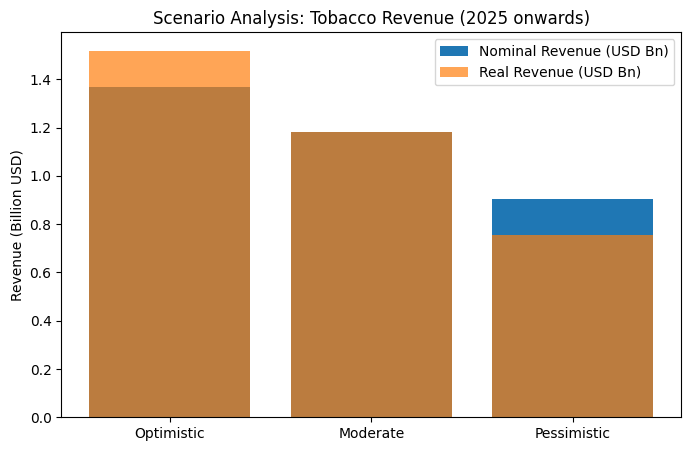

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Baseline Data (from your merged_df) ---
data = {
    "year": [2022, 2023, 2024, 2025],
    "total_volume_kg": [208279247, 295660862, 231678225, 348073973],
    "avg_price_usd": [3.02, 3.00, 3.46, 3.40],
    "revenue_usd": [6.30e8, 8.86e8, 8.02e8, 1.18e9],
    "inflation_rate_pct": [193.00, 667.36, 736.11, 92.17]
}
baseline_df = pd.DataFrame(data)

# Use latest year as reference
latest_year = baseline_df["year"].max()
baseline = baseline_df[baseline_df["year"] == latest_year].iloc[0]

# --- Scenario definitions ---
scenarios = {
    "Optimistic": {"rainfall_effect": 1.10, "price_effect": 1.05, "inflation_effect": 0.90},
    "Moderate":   {"rainfall_effect": 1.00, "price_effect": 1.00, "inflation_effect": 1.00},
    "Pessimistic": {"rainfall_effect": 0.85, "price_effect": 0.90, "inflation_effect": 1.20}
}

results = []
for scenario, effects in scenarios.items():
    # Adjusted values
    volume = baseline["total_volume_kg"] * effects["rainfall_effect"]
    price = baseline["avg_price_usd"] * effects["price_effect"]
    nominal_revenue = volume * price
    
    # Adjusted inflation
    inflation_factor = effects["inflation_effect"]
    real_revenue = nominal_revenue / inflation_factor
    
    results.append({
        "Scenario": scenario,
        "Projected_Volume_kg": round(volume, 2),
        "Projected_Price_usd": round(price, 2),
        "Nominal_Revenue_usd": round(nominal_revenue, 2),
        "Real_Revenue_usd": round(real_revenue, 2)
    })

scenario_df = pd.DataFrame(results)

# --- Display results ---
print("\nScenario Analysis Results:")
print(scenario_df)

# --- Plot Nominal vs Real Revenue ---
plt.figure(figsize=(8,5))
plt.bar(scenario_df["Scenario"], scenario_df["Nominal_Revenue_usd"]/1e9, label="Nominal Revenue (USD Bn)")
plt.bar(scenario_df["Scenario"], scenario_df["Real_Revenue_usd"]/1e9, label="Real Revenue (USD Bn)", alpha=0.7)
plt.ylabel("Revenue (Billion USD)")
plt.title("Scenario Analysis: Tobacco Revenue (2025 onwards)")
plt.legend()
plt.show()


Optimistic:
Higher rainfall (+10%) and a slight price bump (+5%) push volume and revenues up. Even after adjusting for lower inflation (10% better), real revenue rises sharply to ~$1.52B, the highest among scenarios.

Moderate (baseline case):
Keeps values close to today’s levels. Nominal and real revenue align (~$1.18B) since inflation is neutral.

Pessimistic:
Weaker rainfall (–15%) and lower prices (–10%) shrink volumes. Inflation adds more pressure (+20%).
Real revenue falls steeply to ~$0.75B, signaling real farmer incomes erode badly.

# Shock Analysis


Shock Analysis Summary (averages by category):
       shock_event  total_volume_kg  rainfall_mm  inflation_rate_pct  \
0  Inflation Spike      263669543.5        415.9              701.75   
1           Normal      278176610.0        568.5              142.60   

   revenue_usd  real_revenue_usd  
0  844000000.0        63750000.0  
1  905000000.0       319785000.0  


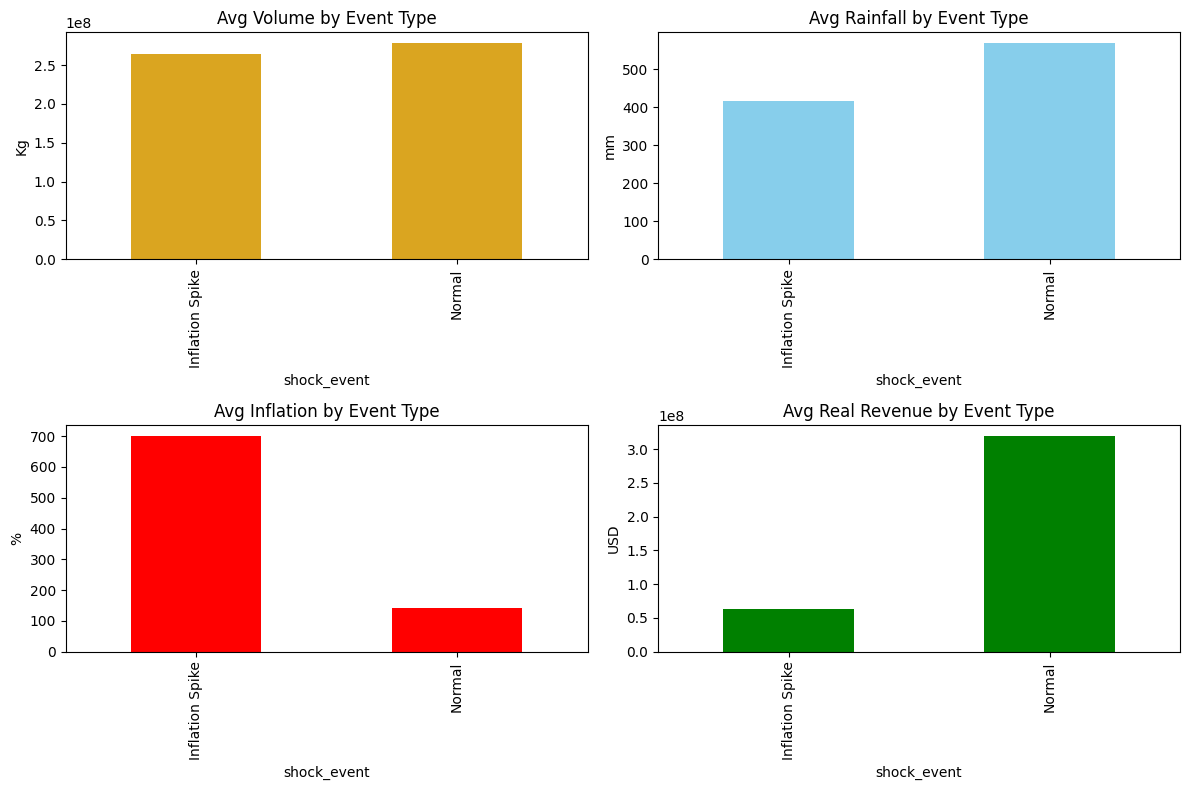

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# === Example data (replace with your merged dataset) ===
data = {
    "year": [2022, 2023, 2024, 2025],
    "total_volume_kg": [208279247, 295660862, 231678225, 348073973],
    "avg_price_usd": [3.02, 3.00, 3.46, 3.40],
    "revenue_usd": [6.30e8, 8.86e8, 8.02e8, 1.18e9],
    "real_revenue_usd": [6.30e8, 1.15e8, 1.25e7, 9.57e6],
    "rainfall_mm": [628.2, 407.5, 424.3, 508.8],
    "inflation_rate_pct": [193.0, 667.4, 736.1, 92.2]
}
df = pd.DataFrame(data)

# === Step 1: Define shocks ===
shock_events = {
    2019: "Drought",
    2020: "Hyperinflation",
    2021: "Hyperinflation",
    2023: "Inflation Spike",
    2024: "Inflation Spike"
}

df["shock_event"] = df["year"].map(shock_events).fillna("Normal")

# === Step 2: Summary Table ===
summary = df.groupby("shock_event")[["total_volume_kg", "rainfall_mm", "inflation_rate_pct",
                                     "revenue_usd", "real_revenue_usd"]].mean().reset_index()

print("\nShock Analysis Summary (averages by category):")
print(summary)

# === Step 3: Plot Comparisons ===
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Volume
df.groupby("shock_event")["total_volume_kg"].mean().plot(kind="bar", ax=axes[0,0], color="goldenrod")
axes[0,0].set_title("Avg Volume by Event Type")
axes[0,0].set_ylabel("Kg")

# Rainfall
df.groupby("shock_event")["rainfall_mm"].mean().plot(kind="bar", ax=axes[0,1], color="skyblue")
axes[0,1].set_title("Avg Rainfall by Event Type")
axes[0,1].set_ylabel("mm")

# Inflation
df.groupby("shock_event")["inflation_rate_pct"].mean().plot(kind="bar", ax=axes[1,0], color="red")
axes[1,0].set_title("Avg Inflation by Event Type")
axes[1,0].set_ylabel("%")

# Real Revenue
df.groupby("shock_event")["real_revenue_usd"].mean().plot(kind="bar", ax=axes[1,1], color="green")
axes[1,1].set_title("Avg Real Revenue by Event Type")
axes[1,1].set_ylabel("USD")

plt.tight_layout()
plt.show()


# Forecasting Model

Forecast Results ===
   year  forecast_volume_kg  forecast_price_usd  forecast_revenue_usd
0  2026           359773462                3.62            1266000000
1  2027           395313616                3.78            1422600000
2  2028           430853770                3.94            1579200000


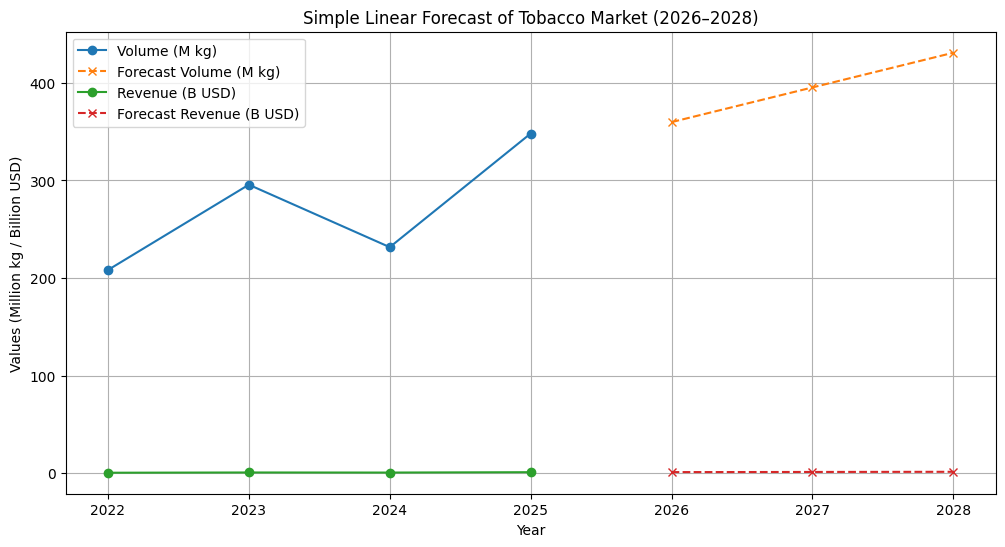

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# --- Sample dataset (replace with your merged data) ---
data = {
    "year": [2022, 2023, 2024, 2025],
    "total_volume_kg": [208279247, 295660862, 231678225, 348073973],
    "avg_price_usd": [3.02, 3.00, 3.46, 3.40],
    "revenue_usd": [6.30e8, 8.86e8, 8.02e8, 1.18e9]
}
df = pd.DataFrame(data)

# --- Forecast function ---
def forecast_series(x_years, y_values, future_years=3):
    X = np.array(x_years).reshape(-1, 1)
    y = np.array(y_values)
    
    model = LinearRegression()
    model.fit(X, y)
    
    future_X = np.arange(max(x_years)+1, max(x_years)+1+future_years).reshape(-1, 1)
    forecast = model.predict(future_X)
    
    return future_X.flatten(), forecast, model

# Forecast volume, price, and revenue
future_years = 3
years = df["year"].tolist()

fut_years_vol, vol_forecast, _ = forecast_series(years, df["total_volume_kg"], future_years)
fut_years_price, price_forecast, _ = forecast_series(years, df["avg_price_usd"], future_years)
fut_years_rev, rev_forecast, _ = forecast_series(years, df["revenue_usd"], future_years)

# Append forecasts to DataFrame
forecast_df = pd.DataFrame({
    "year": fut_years_vol,
    "forecast_volume_kg": vol_forecast.astype(int),
    "forecast_price_usd": price_forecast.round(2),
    "forecast_revenue_usd": rev_forecast.astype(int)
})

print("Forecast Results ===")
print(forecast_df)

# --- Plot forecasts ---
plt.figure(figsize=(12, 6))

plt.plot(df["year"], df["total_volume_kg"]/1e6, marker="o", label="Volume (M kg)")
plt.plot(fut_years_vol, vol_forecast/1e6, marker="x", linestyle="--", label="Forecast Volume (M kg)")

plt.plot(df["year"], df["revenue_usd"]/1e9, marker="o", label="Revenue (B USD)")
plt.plot(fut_years_rev, rev_forecast/1e9, marker="x", linestyle="--", label="Forecast Revenue (B USD)")

plt.title("Simple Linear Forecast of Tobacco Market (2026–2028)")
plt.xlabel("Year")
plt.ylabel("Values (Million kg / Billion USD)")
plt.legend()
plt.grid(True)
plt.show()


# Recommandations

# Conclusion